# Logistic Regression Multiclass Classification

This notebook implements a complete machine learning pipeline for multiclass classification of coronary artery stenosis using Logistic Regression.

## Execution Order:
1. **Imports**: Load all required libraries
2. **Load Dataset**: Import and prepare the raw data
3. **Data Cleaning & Preprocessing**: Clean data, handle missing values, and prepare features
4. **Feature Selection**: Select most informative features
5. **SMOTE Oversampling**: Balance classes using synthetic oversampling
6. **Model Training**: Train Logistic Regression classifier
7. **Overfitting Check**: Compare training vs. test performance
8. **Model Evaluation**: Comprehensive evaluation metrics and confusion matrix
9. **ROC & PR Curves**: Visualize model performance across classes


## 1. Imports

This cell imports all necessary libraries for data manipulation, preprocessing, model training, and evaluation. Key libraries include:
- **pandas/numpy**: Data manipulation and numerical operations
- **sklearn**: Machine learning tools (preprocessing, feature selection, metrics, cross-validation)
- **sklearn.linear_model**: Logistic Regression classifier
- **imblearn**: SMOTE for handling class imbalance
- **matplotlib**: Visualization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    recall_score, precision_score, f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from scipy.sparse import issparse


## 2. Load Dataset

This cell loads the CSV dataset and performs initial data preparation:
- Reads the CSV file with semicolon separator
- Converts European number format (commas to dots)
- Automatically converts numeric columns to appropriate data types
- Separates features (X) from the target variable (y = OUTCOME_3Kat_KHK)
- The target has 3 classes: 0 (No Stenosis), 1 (Non-significant stenosis), 2 (Significant Stenosis)


In [2]:
data = pd.read_csv(
    'T49.2_Sep2025_1_StGallen.csv',
    sep=';',
    na_values=["", " ", "NA", "N/A", "NULL"]
)

data = data.replace(",", ".", regex=True)

for col in data.columns:
    temp = pd.to_numeric(data[col], errors="coerce")
    if temp.notna().sum() == len(data[col]):
        data[col] = temp

data = data.apply(pd.to_numeric, errors='ignore')

X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]


/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_56556/2873073688.py:1: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(
/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_56556/2873073688.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


## 3. Data Cleaning & Preprocessing

This cell performs comprehensive data cleaning and preprocessing:

**Data Cleaning:**
- Removes dependent variables (e.g., LDL, HDL, cholesterol components) that are directly derived from other features
- Identifies categorical and numerical features
- Removes highly correlated features (correlation > 0.95) to reduce redundancy and prevent multicollinearity

**Train/Test Split:**
- Splits data into 75% training and 25% test set
- Uses stratified split to maintain class distribution in both sets

**Preprocessing Pipeline:**
- **Categorical features**: Most frequent imputation + One-Hot Encoding
- **Numerical features**: kNN Imputation (k=5) + Standard Scaling
- Falls back to IterativeImputer or Median imputation if kNN fails
- Fits preprocessor on training data and transforms both training and test sets


In [3]:
columns_to_drop = [
    "remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol",
    "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"
]
data = data.drop(columns_to_drop, axis=1)

manual_categorical = [
    "geschlecht", "currsmo0", "diabetes_ADA_final_0",
    "ANY_OPE", "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

for col in manual_categorical:
    if col in data.columns:
        data[col] = data[col].astype(str)

X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_features = [col for col in numerical_features if col not in categorical_features]

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

cat_preprocessor = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

try:
    num_preprocessor = SklearnPipeline(steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ])
    print("Using KNNImputer + StandardScaler")
except:
    try:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", IterativeImputer(random_state=42, max_iter=10)),
            ("scaler", StandardScaler())
        ])
        print("Using IterativeImputer + StandardScaler (fallback)")
    except:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        print("Using Median Imputer + StandardScaler (fallback)")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_preprocessor, categorical_features),
        ("num", num_preprocessor, numerical_features)
    ],
    remainder="passthrough"
)

preprocessor.fit(X_train, y_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

print(f"\nTransformed shapes:")
print(f"  Training: {X_train_transformed.shape}")
print(f"  Test: {X_test_transformed.shape}")


Categorical features: 7
Numerical features: 634
Removing 428 highly correlated features
After cleaning - Numerical: 206, Categorical: 7
Using KNNImputer + StandardScaler

Transformed shapes:
  Training: (1732, 224)
  Test: (578, 224)


In [4]:
np.random.seed(42)

K_FEATURES = 100
SMOTE_K_NEIGHBORS = 3

selector = SelectKBest(mutual_info_classif, k=K_FEATURES)
X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)

print(f"Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

smote = SMOTE(random_state=42, k_neighbors=SMOTE_K_NEIGHBORS)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

print(f"\nClass distribution before SMOTE:")
class_counts_before = pd.Series(y_train).value_counts().sort_index()
for cls, count in class_counts_before.items():
    class_name = {0: "No Stenosis", 1: "Non-significant stenosis", 2: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

print(f"\nClass distribution after SMOTE:")
class_counts_after = pd.Series(y_train_balanced).value_counts().sort_index()
for cls, count in class_counts_after.items():
    class_name = {0: "No Stenosis", 1: "Non-significant stenosis", 2: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train_balanced) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

print(f"\nTraining set size: {X_train_balanced.shape[0]} samples, {X_train_balanced.shape[1]} features")


Selected 100 features out of 224

Class distribution before SMOTE:
  No Stenosis (Class 0): 272 samples (15.7%)
  Non-significant stenosis (Class 1): 474 samples (27.4%)
  Significant Stenosis (Class 2): 986 samples (56.9%)

Class distribution after SMOTE:
  No Stenosis (Class 0): 986 samples (33.3%)
  Non-significant stenosis (Class 1): 986 samples (33.3%)
  Significant Stenosis (Class 2): 986 samples (33.3%)

Training set size: 2958 samples, 100 features


## 5. Model Training

This cell builds and trains the Logistic Regression model:
- Creates Logistic Regression classifier with multinomial loss and balanced class weights
- Performs 5-fold cross-validation to assess model performance
- Trains final model on balanced training set
- Makes predictions on test set


In [5]:
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=cv_strategy, scoring='balanced_accuracy')

model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test_selected)
y_proba = model.predict_proba(X_test_selected)

print(f"Mean Cross-Validation Balanced Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Mean Cross-Validation Balanced Accuracy: 0.6028 (+/- 0.0084)


/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multino

## 6. Model Evaluation

This cell performs comprehensive model evaluation:
- Calculates classification metrics (accuracy, balanced accuracy, precision, recall, F1)
- Generates confusion matrix
- Provides per-class performance metrics
- Evaluates model performance on the test set


MODEL EVALUATION

Overall Accuracy: 0.4896
Balanced Accuracy: 0.4659
Mean CV Balanced Accuracy: 0.6028

Classification Report:
                          precision    recall  f1-score   support

             No Stenosis       0.32      0.54      0.40        91
Non-significant stenosis       0.29      0.28      0.29       158
    Significant Stenosis       0.69      0.57      0.63       329

                accuracy                           0.49       578
               macro avg       0.44      0.47      0.44       578
            weighted avg       0.52      0.49      0.50       578


Confusion Matrix:


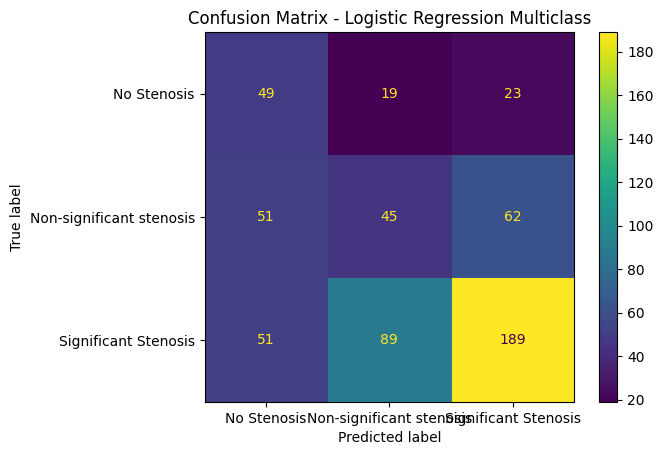


Per-Class Recall:
  No Stenosis (Class 0): 0.5385
  Non-significant stenosis (Class 1): 0.2848
  Significant Stenosis (Class 2): 0.5745


In [6]:
print("=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

accuracy = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Mean CV Balanced Accuracy: {cv_scores.mean():.4f}")

print("\n" + "=" * 80)
print("Classification Report:")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]))

print("\n" + "=" * 80)
print("Confusion Matrix:")
print("=" * 80)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]).plot()
plt.title("Confusion Matrix - Logistic Regression Multiclass")
plt.show()

recall_class2 = recall_score(y_test, y_pred, labels=[2], average=None)[0]
recall_class0 = recall_score(y_test, y_pred, labels=[0], average=None)[0]
recall_class1 = recall_score(y_test, y_pred, labels=[1], average=None)[0]

print(f"\nPer-Class Recall:")
print(f"  No Stenosis (Class 0): {recall_class0:.4f}")
print(f"  Non-significant stenosis (Class 1): {recall_class1:.4f}")
print(f"  Significant Stenosis (Class 2): {recall_class2:.4f}")


## 7. Overfitting Check

This cell compares training and test set performance to detect overfitting:
- Calculates metrics on both training and test sets
- Compares balanced accuracy, recall, and overall accuracy
- Identifies performance gaps that indicate overfitting
- Helps validate model generalization


In [ ]:
y_pred_train = model.predict(X_train_balanced)

train_recall_class2 = recall_score(y_train_balanced, y_pred_train, labels=[2], average=None)[0]
test_recall_class2 = recall_score(y_test, y_pred, labels=[2], average=None)[0]

train_bal_acc = balanced_accuracy_score(y_train_balanced, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred)

train_acc = accuracy_score(y_train_balanced, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 2)")
print("=" * 80)
print(f"\nRecall (Significant Stenosis - Class 2):")
print(f"  Training: {train_recall_class2:.4f}")
print(f"  Test:     {test_recall_class2:.4f}")
print(f"  Gap:      {train_recall_class2 - test_recall_class2:.4f}")
print()
print(f"Balanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Regular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")
print()

gap_recall = train_recall_class2 - test_recall_class2
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("Model shows good generalization (small gap between train/test)")
    print(f"  Recall gap (Class 2): {gap_recall:.4f} (good)")
    print(f"  Balanced accuracy gap: {gap_bal:.4f} (good)")


## 8. ROC and Precision-Recall Curves

This cell visualizes model performance with multiclass ROC and Precision-Recall curves:
- Plots ROC curves for each class (One-vs-Rest approach)
- Plots Precision-Recall curves for each class
- Shows AUC and Average Precision for each class
- Provides visual assessment of model performance across all classes


In [ ]:
classes = model.classes_

class_names = {
    0: "No Stenosis",
    1: "Non-significant stenosis",
    2: "Significant Stenosis"
}

Y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_names[cls]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle=":", lw=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Logistic Regression Multiclass Classification")
ax.legend(loc="lower right")

ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, lw=2, label=f"{class_names[cls]} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves - Logistic Regression Multiclass Classification")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()
